#### Importing Datasets

In [4]:
import pandas as pd

In [25]:
cbe_bank_reviews = pd.read_csv('../data/processed/cbe_bank_reviews_clean.csv')
boa_bank_reviews = pd.read_csv('../data/processed/boa_bank_reviews_clean.csv')
dashen_bank_reviews = pd.read_csv('../data/processed/dashen_bank_reviews_clean.csv')
# cbe_bank_reviews.head()

In [26]:
all_reviews = pd.concat([cbe_bank_reviews, boa_bank_reviews, dashen_bank_reviews], ignore_index=False)

#### Doing further preprocessing

In [6]:
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize
from nltk.corpus import stopwords
import re

In [7]:
import nltk
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
def modular_nlp_pipeline(text):
    # 1. Cleaning
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())

    # 2. Tokenization
    tokens = word_tokenize(text)

    # 3. Stop-word removal & Lemmatization
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    processed = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(processed)


In [27]:
all_reviews['cleaned_review'] = all_reviews['review'].apply(modular_nlp_pipeline)


In [28]:
all_reviews.shape

(1684, 6)

In [29]:
all_reviews.head()

,rating,review,date,bank,source,cleaned_review
0,5,incredible,2026-05-14,CBE,Google Play Store,incredible
1,5,best app for financial sector,2026-05-14,CBE,Google Play Store,best app financial sector
2,5,it's a good application,2026-05-13,CBE,Google Play Store,good application
3,5,"Nice, but I can't get some recently transactio...",2026-05-13,CBE,Google Play Store,nice get recently transaction please try keep ...
4,1,Very Secure but very poor interface and limite...,2026-05-13,CBE,Google Play Store,secure poor interface limited history service ...


In [30]:
# dropping too short reviews
all_reviews = all_reviews[all_reviews['cleaned_review'].str.split().apply(len) > 2]

In [31]:
all_reviews.shape

(1269, 6)

#### Sentiment Analysis

In [1]:
import torch

In [2]:
import numpy as np
from transformers import pipeline

c:\Users\Administrator\KAIM_projects\fintech-review-analytics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
sentiment_pip = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english", 
    truncation=True
)

c:\Users\Administrator\KAIM_projects\fintech-review-analytics\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Administrator\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 104/104 [00:

In [21]:
def classify_review(review):
    result = sentiment_pip(review)[0]
    return pd.Series({'sentiment': result['label'], 'confidence': result['score']})

In [35]:
all_reviews[['sentiment_label', 'sentiment_score']] = all_reviews['cleaned_review'].apply(classify_review)

In [ ]:
all_reviews.head()

,cleaned_review,sentiment,confidence
0,incredible,POSITIVE,0.999875
1,best app financial sector,POSITIVE,0.999521
2,good application,POSITIVE,0.999855
3,nice get recently transaction please try keep ...,NEGATIVE,0.932748
4,secure poor interface limited history service ...,NEGATIVE,0.999277


#### Summary of the information

In [38]:
rating_summary = (
    all_reviews
    .groupby("rating")
    .agg(
        mean_confidence=('sentiment_score', 'mean'),
        positive_rate=('sentiment_label', lambda x: (x == 'POSITIVE').mean()),
        negative_rate=('sentiment_label', lambda x: (x == 'NEGATIVE').mean()),
        review_count=('sentiment_label', 'count')
    )
)

rating_summary

,mean_confidence,positive_rate,negative_rate,review_count
rating,,,,
1,0.976733,0.164835,0.835165,455
2,0.971319,0.231707,0.768293,82
3,0.950881,0.309524,0.690476,84
4,0.932772,0.536585,0.463415,82
5,0.968227,0.837456,0.162544,566


In [42]:
bank_summary = (
    all_reviews
    .groupby("bank")
    .agg(
        mean_confidence=("sentiment_score", "mean"),
        positive_rate=("sentiment_label", lambda x: (x == "POSITIVE").mean()),
        negative_rate=("sentiment_label", lambda x: (x == "NEGATIVE").mean()),
        avg_rating=("rating", "mean")
    )
    .reset_index()
)
bank_summary

,bank,mean_confidence,positive_rate,negative_rate,avg_rating
0,BOA,0.969648,0.300000,0.700000,2.165854
1,CBE,0.962136,0.545198,0.454802,3.327684
2,DASHEN,0.970866,0.637624,0.362376,3.887129


In [44]:
bank_rating_summary = (
    all_reviews
    .groupby(["bank", "rating"])
    .agg(
        mean_confidence=("sentiment_score", "mean"),
        review_count=("sentiment_label", "count")
    )
    .reset_index()
)

bank_rating_summary

,bank,rating,mean_confidence,review_count
0,BOA,1,0.973889,259
1,BOA,2,0.946874,20
2,BOA,3,0.992240,24
3,BOA,4,0.910216,18
4,BOA,5,0.968351,89
5,CBE,1,0.978464,100
6,CBE,2,0.972923,30
7,CBE,3,0.942499,33
8,CBE,4,0.937236,36
9,CBE,5,0.959479,155


##### Visualizing the summary

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

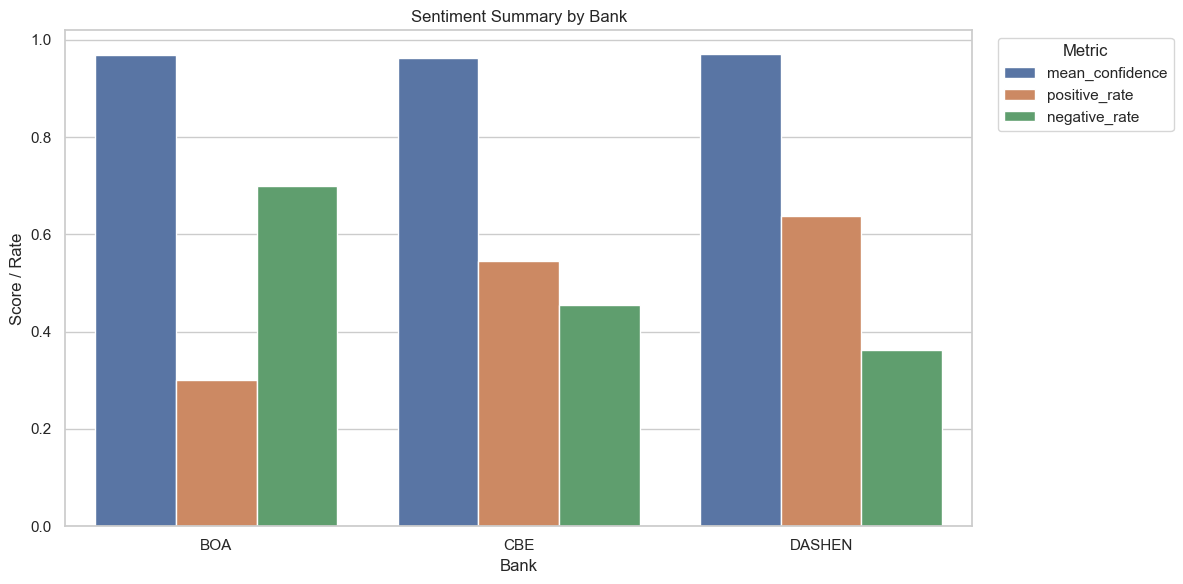

In [49]:
sns.set_theme(style="whitegrid")

# Normalize label case if needed
all_reviews["sentiment_label"] = all_reviews["sentiment_label"].str.lower()

# 1) Bank summary: grouped bar chart
bank_plot = bank_summary.melt(
    id_vars="bank",
    value_vars=["mean_confidence", "positive_rate", "negative_rate"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=bank_plot, x="bank", y="value", hue="metric")
plt.title("Sentiment Summary by Bank")
plt.ylabel("Score / Rate")
plt.xlabel("Bank")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


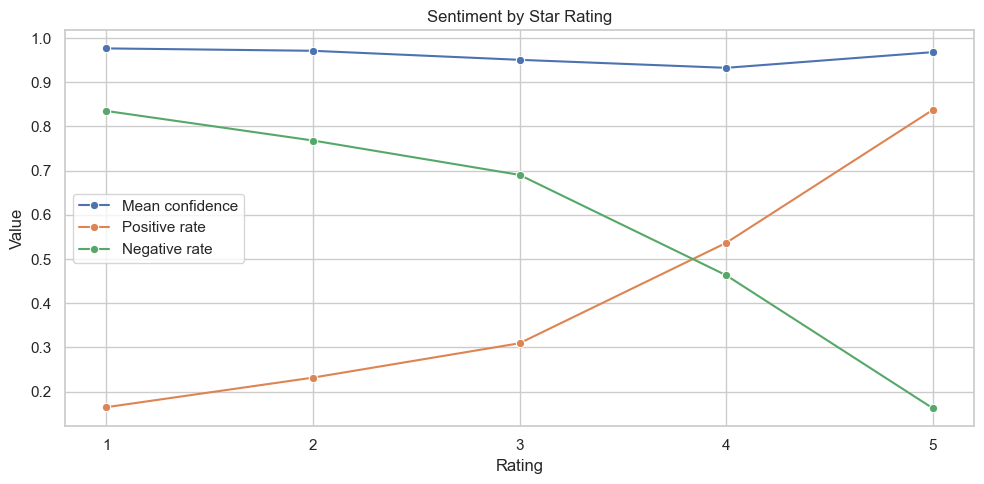

In [51]:
# 2) Rating summary: line chart
rating_plot = rating_summary.sort_values("rating")

plt.figure(figsize=(10, 5))
sns.lineplot(data=rating_plot, x="rating", y="mean_confidence", marker="o", label="Mean confidence")
sns.lineplot(data=rating_plot, x="rating", y="positive_rate", marker="o", label="Positive rate")
sns.lineplot(data=rating_plot, x="rating", y="negative_rate", marker="o", label="Negative rate")

plt.title("Sentiment by Star Rating")
plt.xlabel("Rating")
plt.ylabel("Value")
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

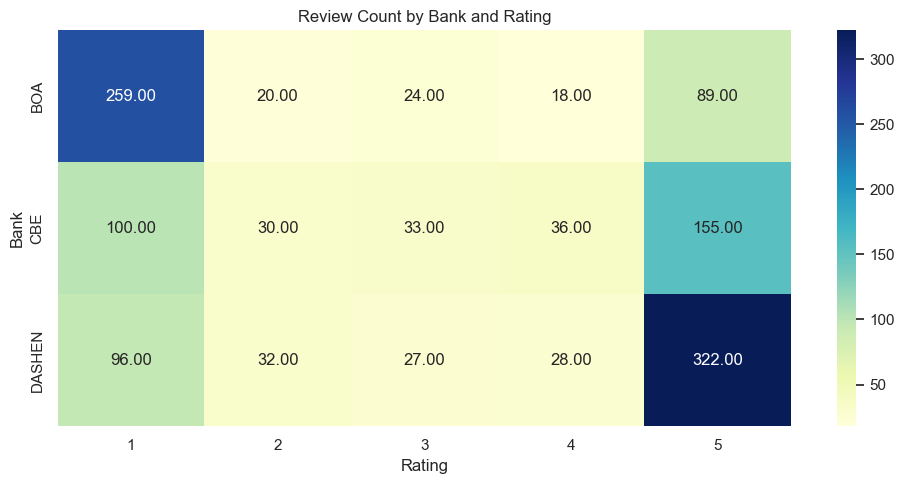

In [53]:
# 3) Bank-rating summary: heatmap
heatmap_data = bank_rating_summary.pivot(index="bank", columns="rating", values="review_count")

plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Review Count by Bank and Rating")
plt.xlabel("Rating")
plt.ylabel("Bank")
plt.tight_layout()
plt.show()

#### Exporting to csv

In [54]:
banks_sentiment = all_reviews[["bank", "cleaned_review","rating", "sentiment_label", "sentiment_score"]]

In [55]:
banks_sentiment.to_csv('../data/processed/banks_sentiment.csv', index=False)